In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

print("Ready")

Ready


In [3]:
# Download Coca-Cola and Pepsi
tickers = ["KO", "PEP"]
raw = yf.download(tickers, start="2010-01-01",
                  end="2024-01-01", auto_adjust=True)
prices = raw["Close"]
prices.columns = prices.columns.get_level_values(0)

ko = prices["KO"].squeeze()
pep = prices["PEP"].squeeze()

print(f"KO observations : {len(ko)}")
print(f"PEP observations : {len(pep)}")
print(f"Date range: {ko.index[0].date()} to {ko.index[-1].date()}")

[*********************100%***********************]  2 of 2 completed

KO observations : 3522
PEP observations : 3522
Date range: 2010-01-04 to 2023-12-29


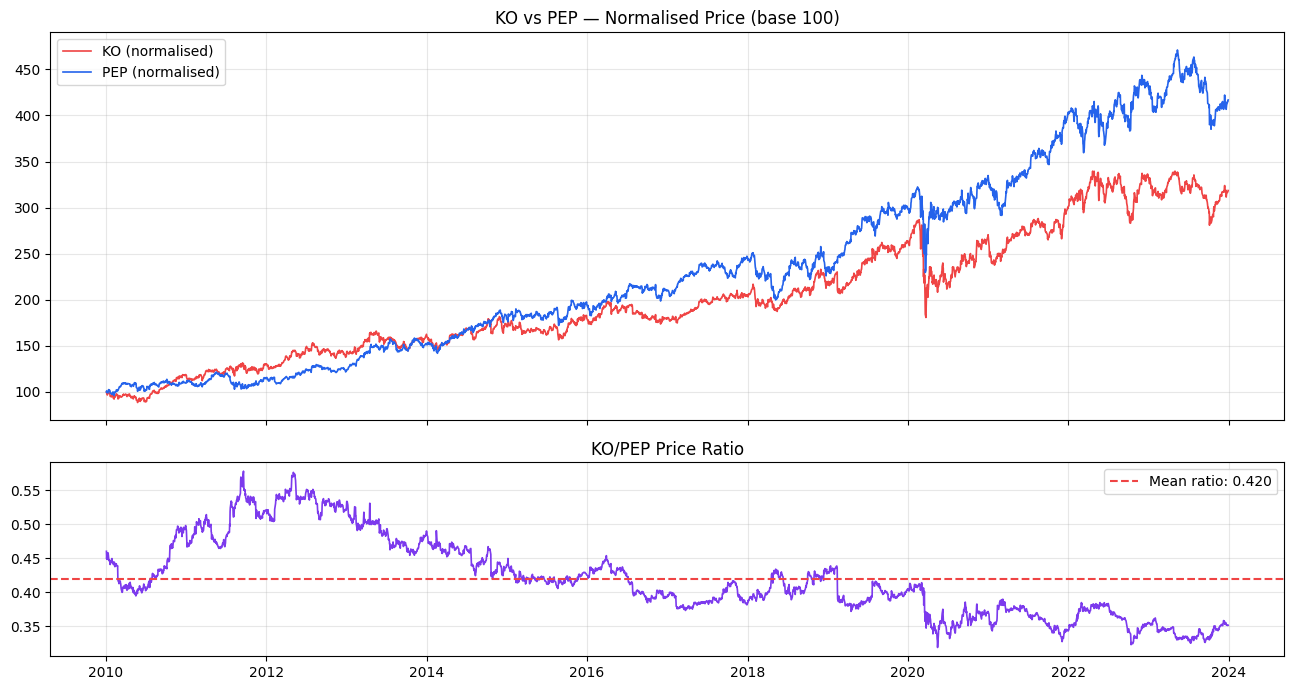

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Panel 1: Normalised prices (both start at 100)
ko_norm  = ko  / ko.iloc[0]  * 100
pep_norm = pep / pep.iloc[0] * 100

ax1.plot(ko_norm,  color='#ef4444', lw=1.2, label='KO (normalised)')
ax1.plot(pep_norm, color='#2563eb', lw=1.2, label='PEP (normalised)')
ax1.set_title('KO vs PEP — Normalised Price (base 100)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Price ratio
ratio = ko / pep
ax2.plot(ratio, color='#7c3aed', lw=1.2)
ax2.axhline(ratio.mean(), color='#ef4444',
            lw=1.5, linestyle='--', label=f'Mean ratio: {ratio.mean():.3f}')
ax2.set_title('KO/PEP Price Ratio')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Engle-Granger cointegration test
score, pvalue, _ = coint(ko, pep)

print("=" * 45)
print("  KO/PEP COINTEGRATION TEST")
print("=" * 45)
print(f"  Test statistic : {score:.4f}")
print(f"  P-value        : {pvalue:.6f}")
print(f"  Cointegrated?  : {'YES' if pvalue < 0.05 else 'NO'}")
print("=" * 45)

if pvalue < 0.05:
    print(f"\n  p={pvalue:.4f} < 0.05 — spread is stationary")
    print(f"  Safe to build a pairs trading strategy")
else:
    print(f"\n  p={pvalue:.4f} > 0.05 — spread is NOT stationary")
    print(f"  Do NOT trade this pair")

  KO/PEP COINTEGRATION TEST
  Test statistic : -4.1726
  P-value        : 0.004012
  Cointegrated?  : YES

  p=0.0040 < 0.05 — spread is stationary
  Safe to build a pairs trading strategy


In [6]:
# OLS regression: KO = alpha + beta * PEP
X     = sm.add_constant(pep)
model = sm.OLS(ko, X).fit()
alpha       = model.params.iloc[0]
hedge_ratio = model.params.iloc[1]

print(f"Hedge ratio (beta) : {hedge_ratio:.4f}")
print(f"Alpha              : {alpha:.4f}")
print(f"R-squared          : {model.rsquared:.4f}")
print(f"\nInterpretation: For every 1 share of PEP,")
print(f"short {hedge_ratio:.4f} shares of KO to hedge")

# Calculate spread
spread = ko - hedge_ratio * pep

# Test spread for stationarity
adf_result = adfuller(spread.dropna())
print(f"\nSpread ADF p-value : {adf_result[1]:.6f}")
print(f"Spread stationary? : {'YES' if adf_result[1] < 0.05 else 'NO'}")

Hedge ratio (beta) : 0.2941
Alpha              : 9.1474
R-squared          : 0.9719

Interpretation: For every 1 share of PEP,
short 0.2941 shares of KO to hedge

Spread ADF p-value : 0.000732
Spread stationary? : YES


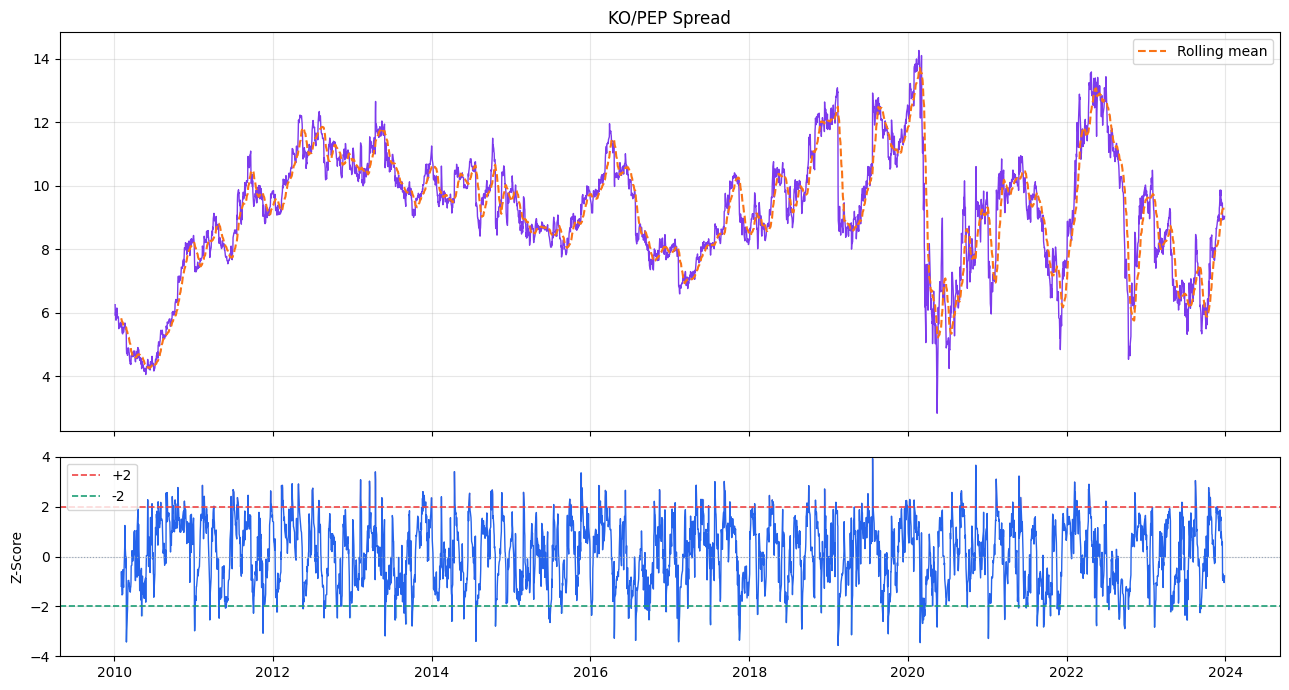

Days spread below -2 : 168
Days spread above +2 : 196


In [7]:
# Rolling z-score of the spread
window      = 20
spread_mean = spread.rolling(window).mean()
spread_std  = spread.rolling(window).std()
zscore      = (spread - spread_mean) / spread_std

# Visualise
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

ax1.plot(spread, color='#7c3aed', lw=1)
ax1.plot(spread_mean, color='#f97316', lw=1.5,
         linestyle='--', label='Rolling mean')
ax1.set_title('KO/PEP Spread')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(zscore, color='#2563eb', lw=1)
ax2.axhline( 2, color='#ef4444', lw=1.2,
             linestyle='--', label='+2')
ax2.axhline(-2, color='#1D9E75', lw=1.2,
             linestyle='--', label='-2')
ax2.axhline( 0, color='#94a3b8', lw=0.8, linestyle=':')
ax2.fill_between(zscore.index, zscore, -2,
                 where=(zscore < -2),
                 alpha=0.3, color='#1D9E75')
ax2.fill_between(zscore.index, zscore,  2,
                 where=(zscore >  2),
                 alpha=0.3, color='#ef4444')
ax2.set_ylabel('Z-Score')
ax2.set_ylim(-4, 4)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Days spread below -2 : {(zscore < -2).sum()}")
print(f"Days spread above +2 : {(zscore >  2).sum()}")

In [8]:
# Pairs trading state machine
# Position: +1 = long KO/short PEP, -1 = short KO/long PEP, 0 = flat
pos_list, cp = [], 0

for i in range(len(zscore)):
    if cp == 0 and zscore.iloc[i] < -2:
        cp = 1    # spread cheap: buy KO, short PEP
    elif cp == 0 and zscore.iloc[i] > 2:
        cp = -1   # spread expensive: short KO, buy PEP
    elif cp != 0 and abs(zscore.iloc[i]) < 0.5:
        cp = 0    # spread back to mean: exit
    pos_list.append(cp)

position = pd.Series(pos_list, index=zscore.index)
position = position.shift(1).fillna(0)

# Returns — long KO return - hedge_ratio * PEP return
ko_ret  = np.log(ko  / ko.shift(1)).reindex(position.index).fillna(0)
pep_ret = np.log(pep / pep.shift(1)).reindex(position.index).fillna(0)

# When long (+1): earn KO return, pay PEP return
# When short (-1): earn PEP return, pay KO return
spread_ret = position * (ko_ret - hedge_ratio * pep_ret)

# Transaction costs
trades     = position.diff().abs().fillna(0)
costs      = trades * 0.0006
net_ret    = spread_ret - costs

# Equity curve
equity = (1 + net_ret).cumprod()

# Metrics
ar = net_ret.mean() * 252
av = net_ret.std()  * np.sqrt(252)
sh = (ar - 0.02)   / av
dd = (equity - equity.cummax()) / equity.cummax()

print(f"\n{'='*45}")
print(f"  KO/PEP PAIRS TRADING RESULTS")
print(f"{'='*45}")
print(f"  Ann. Return    : {ar:.2%}")
print(f"  Ann. Volatility: {av:.2%}")
print(f"  Sharpe Ratio   : {sh:.2f}")
print(f"  Max Drawdown   : {dd.min():.2%}")
print(f"  Total trades   : {int(trades.sum())}")
print(f"  Final value    : ${equity.iloc[-1]:.2f}")
print(f"{'='*45}")


  KO/PEP PAIRS TRADING RESULTS
  Ann. Return    : 1.07%
  Ann. Volatility: 9.49%
  Sharpe Ratio   : -0.10
  Max Drawdown   : -29.22%
  Total trades   : 254
  Final value    : $1.09


In [9]:
def pairs_backtest(y, x, hedge_ratio, 
                   entry_z=2.0, exit_z=0.5,
                   window=20, cost_pct=0.0006):
    """
    Pairs trading backtest with configurable parameters.
    """
    # Spread z-score
    spread      = y - hedge_ratio * x
    spread_mean = spread.rolling(window).mean()
    spread_std  = spread.rolling(window).std()
    zscore      = (spread - spread_mean) / spread_std

    # State machine
    pos_list, cp = [], 0
    for i in range(len(zscore)):
        if cp == 0 and zscore.iloc[i] < -entry_z:
            cp = 1
        elif cp == 0 and zscore.iloc[i] > entry_z:
            cp = -1
        elif cp != 0 and abs(zscore.iloc[i]) < exit_z:
            cp = 0
        pos_list.append(cp)

    position = pd.Series(pos_list,
                         index=zscore.index).shift(1).fillna(0)

    # Returns
    y_ret = np.log(y / y.shift(1)).reindex(position.index).fillna(0)
    x_ret = np.log(x / x.shift(1)).reindex(position.index).fillna(0)
    spread_ret = position * (y_ret - hedge_ratio * x_ret)

    # Costs
    trades  = position.diff().abs().fillna(0)
    net_ret = spread_ret - trades * cost_pct
    equity  = (1 + net_ret).cumprod()

    # Metrics
    ar = net_ret.mean() * 252
    av = net_ret.std()  * np.sqrt(252)
    sh = (ar - 0.02)   / av
    dd = (equity - equity.cummax()) / equity.cummax()

    return {
        "ann_ret"  : ar,
        "ann_vol"  : av,
        "sharpe"   : sh,
        "max_dd"   : dd.min(),
        "n_trades" : int(trades.sum()),
        "equity"   : equity
    }

# Test different parameter combinations
print(f"{'Entry Z':>8} {'Exit Z':>8} {'Sharpe':>8} {'Ann Ret':>9} {'Trades':>8}")
print("-" * 45)
for entry in [1.5, 2.0, 2.5]:
    for exit in [0.0, 0.5, 1.0]:
        r = pairs_backtest(ko, pep, hedge_ratio,
                           entry_z=entry, exit_z=exit)
        print(f"{entry:>8.1f} {exit:>8.1f} {r['sharpe']:>8.2f} {r['ann_ret']:>9.2%} {r['n_trades']:>8}")

 Entry Z   Exit Z   Sharpe   Ann Ret   Trades
---------------------------------------------
     1.5      0.0     0.26     5.74%        1
     1.5      0.5    -0.19    -0.07%      386
     1.5      1.0    -0.42    -1.80%      496
     2.0      0.0     0.27     5.83%        1
     2.0      0.5    -0.10     1.07%      254
     2.0      1.0    -0.21     0.30%      284
     2.5      0.0     0.27     5.83%        1
     2.5      0.5    -0.16     0.74%      152
     2.5      1.0    -0.40    -0.43%      154


In [10]:
# Download GLD and SLV
raw2 = yf.download(["GLD", "SLV"],
                    start="2010-01-01",
                    end="2024-01-01", auto_adjust=True)
prices2 = raw2["Close"]
prices2.columns = prices2.columns.get_level_values(0)

gld = prices2["GLD"].squeeze()
slv = prices2["SLV"].squeeze()

# Test cointegration
score2, pvalue2, _ = coint(gld, slv)
print(f"GLD/SLV cointegration p-value: {pvalue2:.6f}")
print(f"Cointegrated? : {'YES' if pvalue2 < 0.05 else 'NO'}")

# Hedge ratio
X2          = sm.add_constant(slv)
model2      = sm.OLS(gld, X2).fit()
hedge_ratio2 = model2.params.iloc[1]
print(f"Hedge ratio   : {hedge_ratio2:.4f}")
print(f"R-squared     : {model2.rsquared:.4f}")

# Run best parameters
result = pairs_backtest(gld, slv, hedge_ratio2,
                        entry_z=2.0, exit_z=0.0)
print(f"\nGLD/SLV Pairs Trading:")
print(f"  Sharpe     : {result['sharpe']:.2f}")
print(f"  Ann Return : {result['ann_ret']:.2%}")
print(f"  Max DD     : {result['max_dd']:.2%}")
print(f"  N Trades   : {result['n_trades']}")

[*********************100%***********************]  2 of 2 completed


GLD/SLV cointegration p-value: 0.968004
Cointegrated? : NO
Hedge ratio   : 2.3362
R-squared     : 0.3407

GLD/SLV Pairs Trading:
  Sharpe     : -0.02
  Ann Return : 0.78%
  Max DD     : -98.98%
  N Trades   : 1


In [11]:
# Download XOM and CVX
raw3 = yf.download(["XOM", "CVX"],
                    start="2010-01-01",
                    end="2024-01-01", auto_adjust=True)
prices3 = raw3["Close"]
prices3.columns = prices3.columns.get_level_values(0)

xom = prices3["XOM"].squeeze()
cvx = prices3["CVX"].squeeze()

# Test cointegration
score3, pvalue3, _ = coint(xom, cvx)
print(f"XOM/CVX cointegration p-value: {pvalue3:.6f}")
print(f"Cointegrated? : {'YES' if pvalue3 < 0.05 else 'NO'}")

# Hedge ratio
X3           = sm.add_constant(cvx)
model3       = sm.OLS(xom, X3).fit()
hedge_ratio3 = model3.params.iloc[1]
print(f"Hedge ratio   : {hedge_ratio3:.4f}")
print(f"R-squared     : {model3.rsquared:.4f}")

# Run backtest if cointegrated
if pvalue3 < 0.05:
    result3 = pairs_backtest(xom, cvx, hedge_ratio3,
                             entry_z=2.0, exit_z=0.0)
    print(f"\nXOM/CVX Pairs Trading:")
    print(f"  Sharpe     : {result3['sharpe']:.2f}")
    print(f"  Ann Return : {result3['ann_ret']:.2%}")
    print(f"  Max DD     : {result3['max_dd']:.2%}")
    print(f"  N Trades   : {result3['n_trades']}")
else:
    print("\nNot cointegrated — skip this pair")

[*********************100%***********************]  2 of 2 completed


XOM/CVX cointegration p-value: 0.645769
Cointegrated? : NO
Hedge ratio   : 0.5254
R-squared     : 0.7954

Not cointegrated — skip this pair


In [13]:
from itertools import combinations

def find_cointegrated_pairs(tickers, start="2015-01-01",
                             end="2024-01-01"):
    """
    Test all pairs in a universe for cointegration.
    Returns ranked list of cointegrated pairs.
    """
    raw = yf.download(tickers, start=start,
                      end=end, auto_adjust=True)
    prices = raw["Close"]
    prices.columns = prices.columns.get_level_values(0)

    results = []
    pairs   = list(combinations(tickers, 2))

    print(f"Testing {len(pairs)} pairs...")

    for t1, t2 in pairs:
        try:
            s1 = prices[t1].dropna()
            s2 = prices[t2].dropna()
            # Align
            s1, s2 = s1.align(s2, join='inner')
            if len(s1) < 252:
                continue
            _, pval, _ = coint(s1, s2)
            results.append({
                "pair"  : f"{t1}/{t2}",
                "pvalue": pval,
                "cointegrated": pval < 0.05
            })
        except:
            continue

    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values("pvalue")

    print(f"\nCointegrated pairs (p < 0.05):")
    print("=" * 40)
    coint_pairs = df_res[df_res["cointegrated"]]
    if len(coint_pairs) == 0:
        print("  None found in this universe")
    else:
        for _, row in coint_pairs.iterrows():
            print(f"  {row['pair']:<15} p={row['pvalue']:.4f}")
    print("=" * 40)
    print(f"\nTop 5 by p-value (all pairs):")
    print(df_res.head().to_string(index=False))

    return df_res

# Test our stock universe
universe = ["KO", "PEP", "JPM", "BAC", "GS",
            "XOM", "CVX", "JNJ", "PFE", "MRK"]

results = find_cointegrated_pairs(universe)

[*********************100%***********************]  10 of 10 completed


Testing 45 pairs...

Cointegrated pairs (p < 0.05):
  KO/PEP          p=0.0095

Top 5 by p-value (all pairs):
   pair   pvalue  cointegrated
 KO/PEP 0.009508          True
 KO/JNJ 0.077288         False
BAC/JNJ 0.079228         False
BAC/PFE 0.080430         False
 KO/MRK 0.114718         False
